In [1]:
import os
import tensorflow as tf
import pandas as pd
import sys
import matplotlib.pyplot as plt
from itertools import permutations, combinations
from matplotlib import rcParams, cycler
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc7 import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [100]:
# Make the permutation matrices
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))#.transpose(0,2,3,1)

perm_combos = tf.one_hot(
    perm_combos,
    3,
    axis=-1,
)
perm_combos = tf.transpose(perm_combos, (0,1,2,4,3))

perm_combos = tf.where(perm_combos == 1.0, 
                  tf.ones_like(perm_combos) * 10.0,   # large positive
                  tf.ones_like(perm_combos) * -10.0)  # large negative

In [5]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [6]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [7]:
new_params = {
    'dLGN_params':[],
    'V1_params':[]
}

index_batch = tf.data.Dataset.from_tensor_slices(np.arange(perm_combos.shape[0]))  
index_batch = index_batch.batch(10)
index_batch = index_batch.prefetch(tf.data.AUTOTUNE)
for i in index_batch:
    n_sample = 100
    batch_size = i.shape[0]

    model = SGCCircuit(bounds=param_bounds, enforce_permutation=tf.tile(perm_combos.numpy()[i], [n_sample,1,1,1,1]))
    model.initialize_random_parameters(2,3, n_sample=batch_size*n_sample)

    optimizer = Optimize(model, epochs=100)
    optimizer.fit(X, Y_true)

    sl = optimizer.outputs['loss_decay'][-1,:].reshape(n_sample,batch_size) # sample loss
    bli = np.array([np.where(sl[:,i] == sl[:,i].min())[0][0] for i in range(batch_size)]) # best loss index
    fe = optimizer.outputs['final_epoch_params'] ## final epoch
    dlgn = fe['dLGN_params'].reshape(n_sample,batch_size,2,3,7,1,1)
    v1 = fe['V1_params'].reshape(n_sample,batch_size,2,1,2,1,1)
    for i in range(batch_size):
        new_params['dLGN_params'].append(dlgn[bli[i],i])
        new_params['V1_params'].append(v1[bli[i],i])

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x0000022E35946220>
Training step = 0, N_exploration_samples = 1000,
min_loss = 1.0310590267181396
med_loss = 12.4283447265625
max_loss = 77.6175308227539

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x0000022E14A11580>
Training step = 0, N_exploration_samples = 1000,
min_loss = 0.7274238467216492
med_loss = 13.41325569152832
max_loss = 85.09259796142578

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x0000022E14A11460>
Training step = 0, N_exploration_samples = 1000,
min_loss = 0.7530275583267212
med_loss = 13.627338409423828
max_loss = 84.21710968017578

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x0000022E14A114C0>
Training step = 0, N_exploration_samples = 1000,
min_loss = 0.9413230419158936
med_loss = 12.176048278808594
max_loss = 122.81385040283203

Optimizer initialized with <keras.optimizers.optimizer_

In [101]:
index_batch = tf.data.Dataset.from_tensor_slices(np.arange(perm_combos.shape[0]))  
index_batch = index_batch.batch(1000)
index_batch = index_batch.prefetch(tf.data.AUTOTUNE)  

dlgn_params = tf.stack(new_params['dLGN_params'], axis = 0)
v1_params = tf.stack(new_params['V1_params'], axis = 0)

optimized_permutation_params = {
    'dLGN_params':[],
    'V1_params':[]
}

permutation_loss_decay = []
for i in index_batch:
    perm = perm_combos.numpy()[i]
    lgn_param = dlgn_params.numpy()[i]
    v1_param = v1_params.numpy()[i]

    
    model = SGCCircuit(bounds = param_bounds, identify=True, enforce_permutation=perm)
    model.load_saved_parameters({'dLGN_params':lgn_param, 'V1_params': v1_param})
    optimizer = Optimize(model, epochs=5000, loss_threshold=0)
    optimizer.fit(X, Y_true)

    permutation_loss_decay.append(optimizer.outputs['loss_decay'])
    optimized_permutation_params['dLGN_params'].append(optimizer.outputs['final_epoch_params']['dLGN_params'])
    optimized_permutation_params['V1_params'].append(optimizer.outputs['final_epoch_params']['V1_params'])

optimized_permutation_params = {
    'dLGN_params': np.concatenate(optimized_permutation_params['dLGN_params'], axis=0), 
    'V1_params': np.concatenate(optimized_permutation_params['V1_params'], axis=0)
}
result =  {
    'loss_decay': np.concatenate(permutation_loss_decay, axis = 1), 
    'params': optimized_permutation_params
}

with open('permutation_test_results.pkl', 'wb') as f:
    pickle.dump(result, f)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x0000022F8DEA7250>
Training step = 0, N_exploration_samples = 1000,
min_loss = 0.24493320286273956
med_loss = 0.9718977212905884
max_loss = 2.747528076171875

Training step = 100, N_exploration_samples = 1000,
min_loss = 0.20977473258972168
med_loss = 0.6718748807907104
max_loss = 1.9056035280227661

Training step = 200, N_exploration_samples = 1000,
min_loss = 0.18335363268852234
med_loss = 0.5154664516448975
max_loss = 1.35159432888031

Training step = 300, N_exploration_samples = 1000,
min_loss = 0.16873273253440857
med_loss = 0.41891026496887207
max_loss = 1.0204592943191528

Training step = 400, N_exploration_samples = 1000,
min_loss = 0.15785366296768188
med_loss = 0.3554859757423401
max_loss = 0.8324979543685913

Training step = 500, N_exploration_samples = 1000,
min_loss = 0.1477007120847702
med_loss = 0.3075120449066162
max_loss = 0.735504686832428

Training step = 600, N_exploration_samples = 1000,

In [20]:
result['loss_decay'][-1].max()

0.2408

(0.0, 70.35)

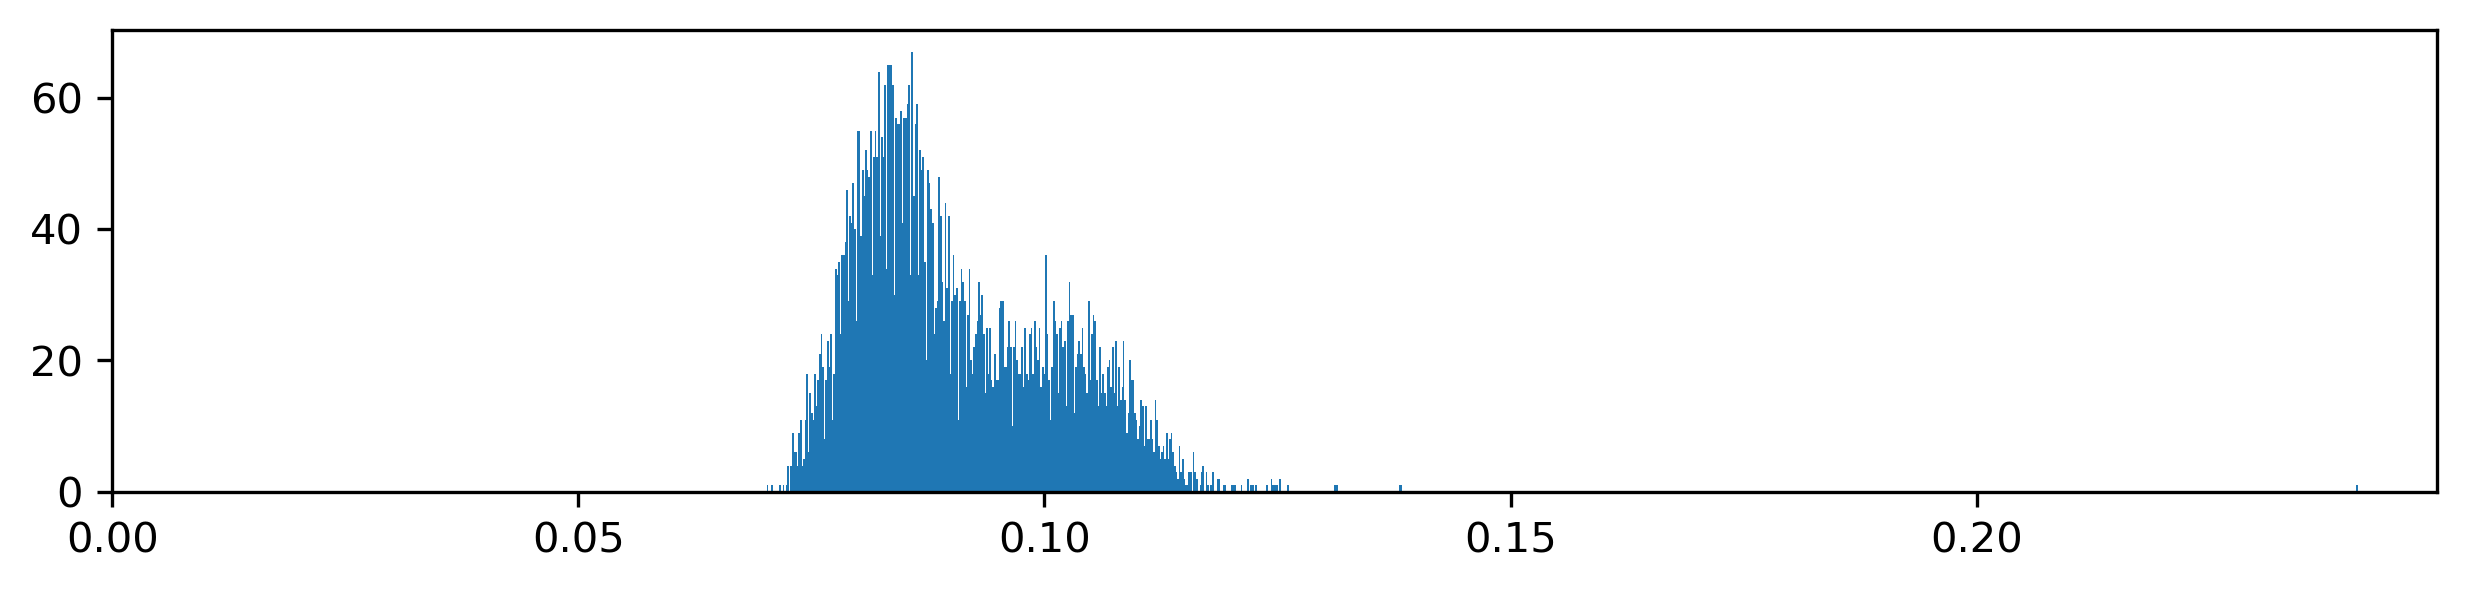

In [104]:
fig, ax = plt.subplots(figsize = (10,2))
plt.hist(result['loss_decay'][-1], bins = 1000)
plt.xlim(0,)
plt.ylim(0,)

In [105]:
best = np.where(result['loss_decay'][-1] == result['loss_decay'][-1].min())[0][0]

In [106]:
best

1291

In [107]:
model = SGCCircuit(bounds = param_bounds, enforce_permutation=perm_combos)

In [108]:
model.load_saved_parameters(optimized_permutation_params)

In [111]:
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

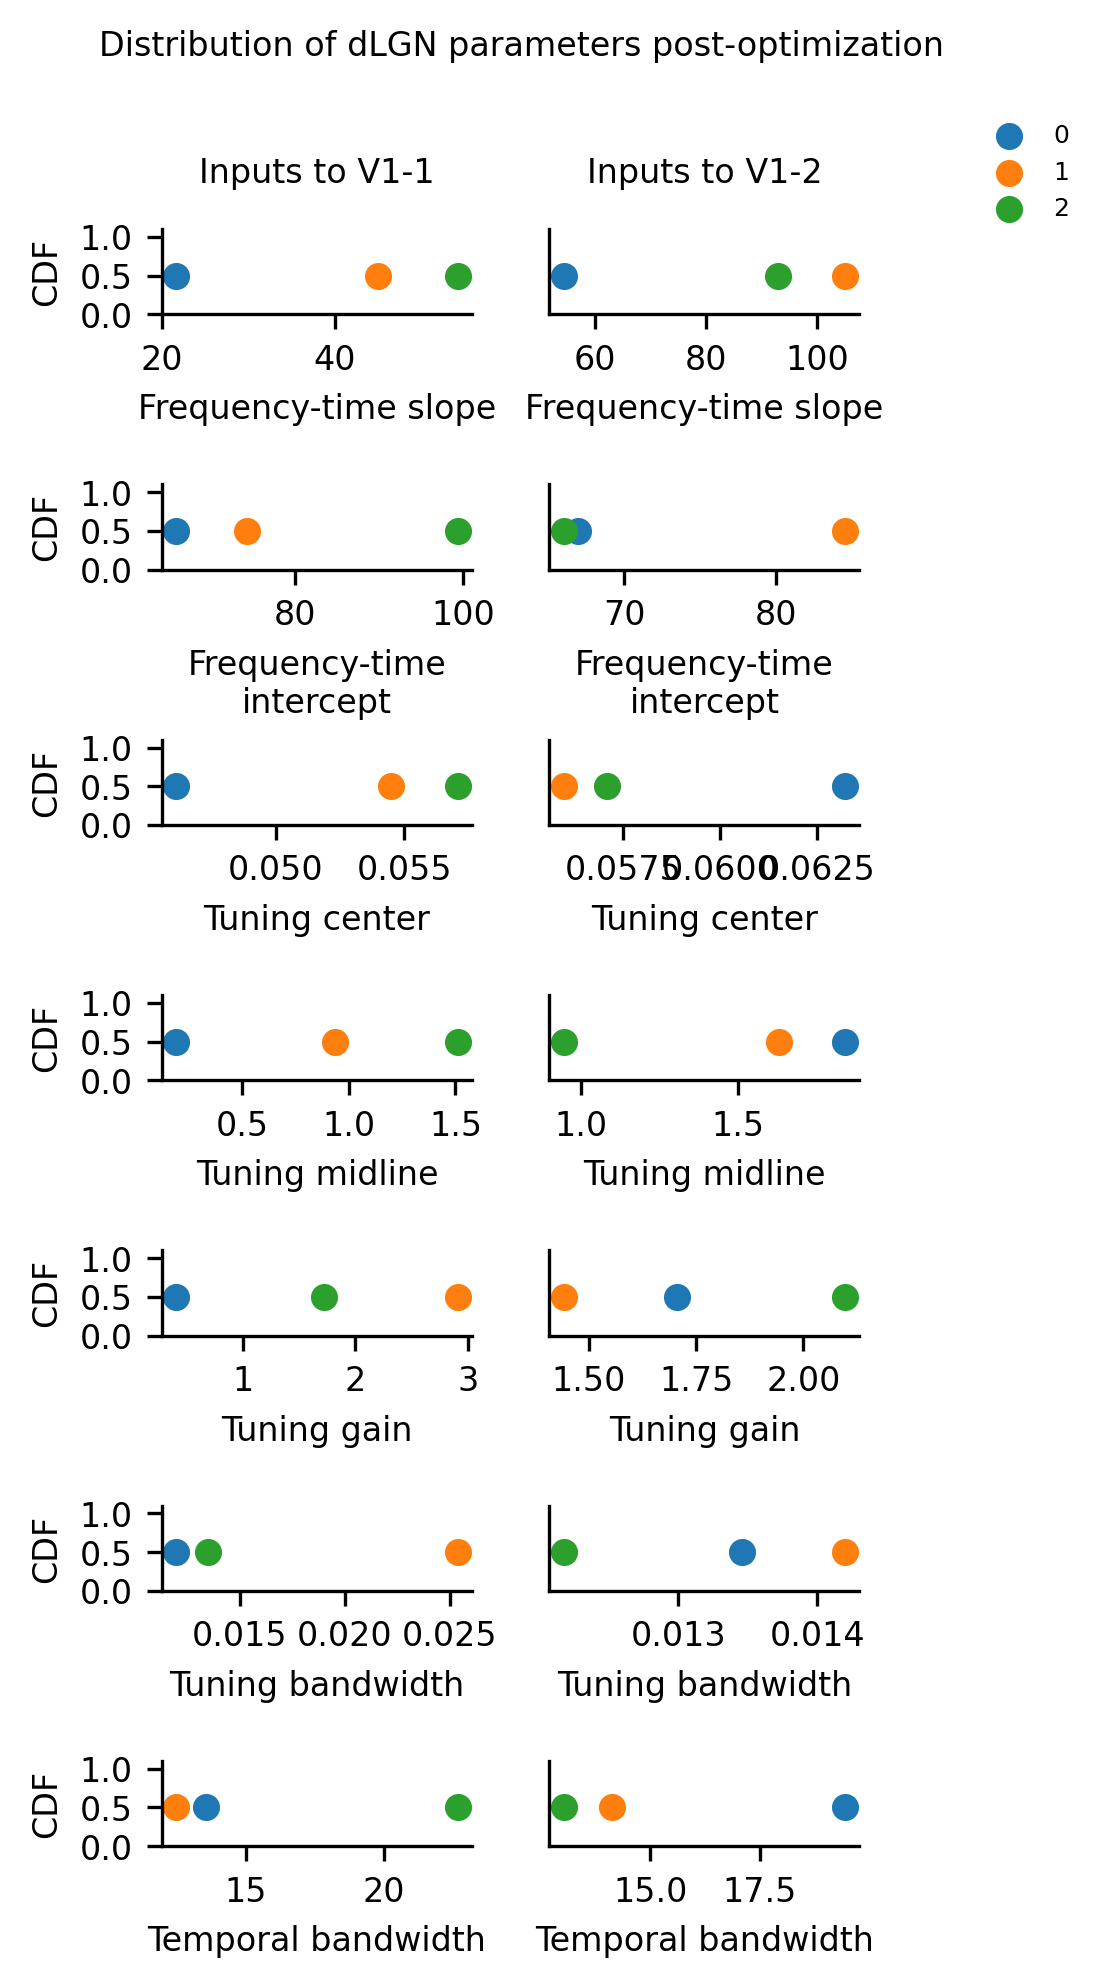

In [109]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(model.params['dLGN_params'][best, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

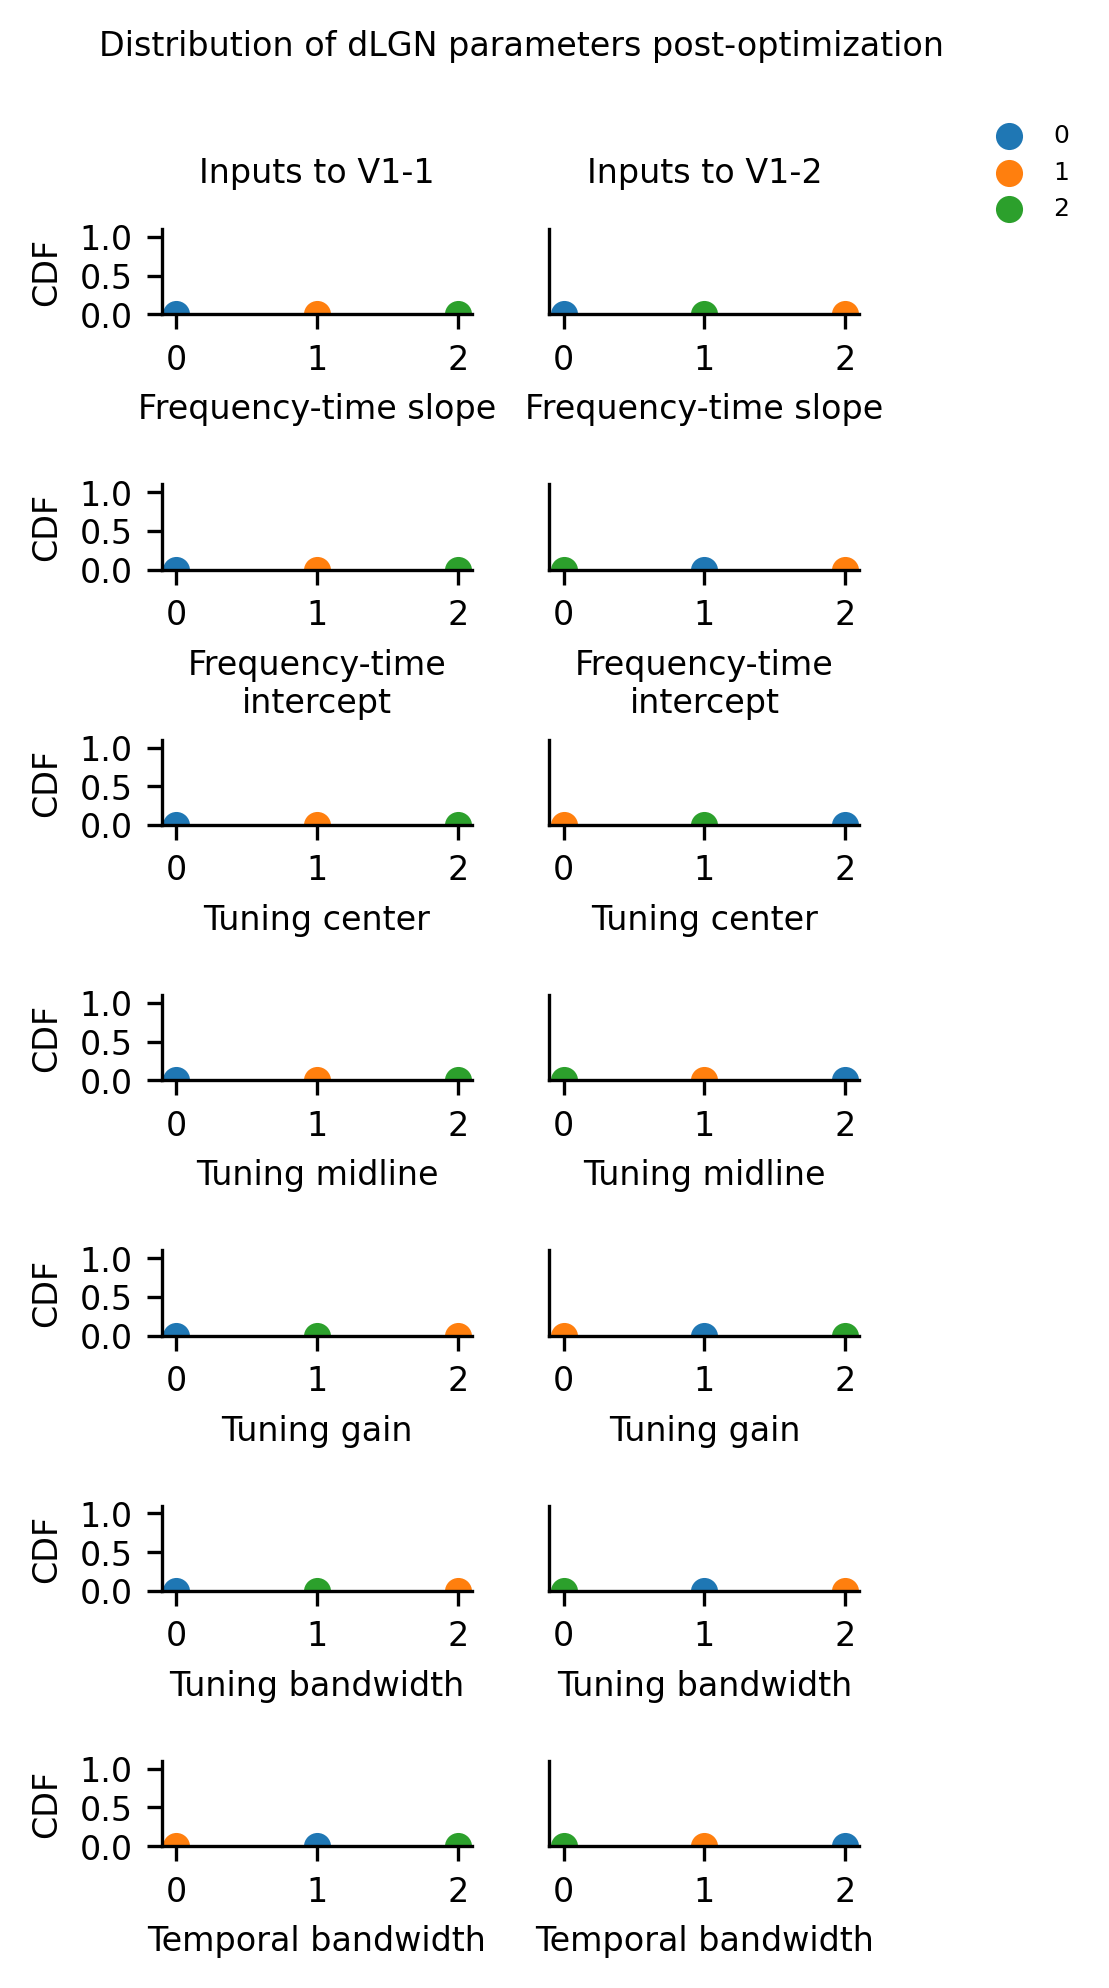

In [112]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(perm_combos[best, row, u, i], [0], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


In [34]:
R = model.predict(X)

ResourceExhaustedError: {{function_node __wrapped__AddV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} failed to allocate memory [Op:AddV2]

NameError: name 'R' is not defined

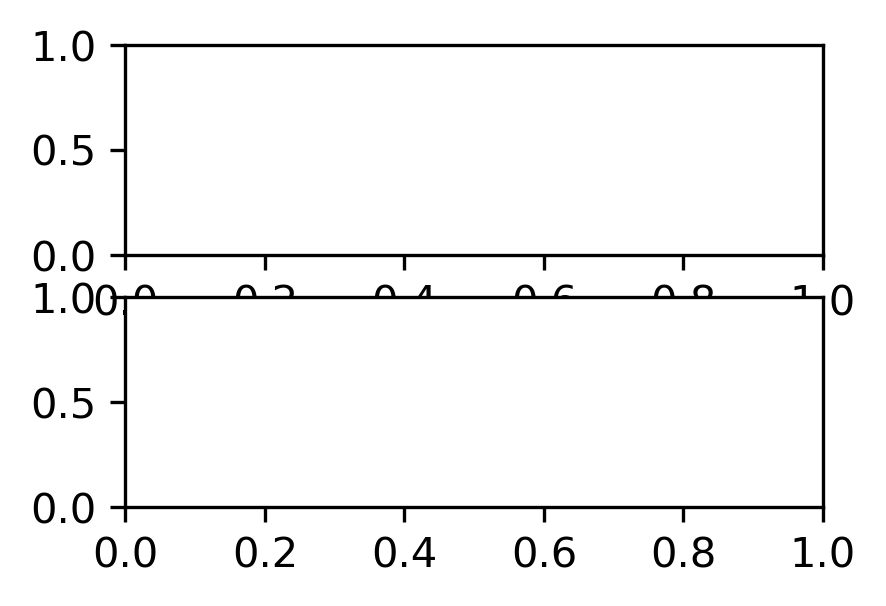

In [33]:
from matplotlib import rcParams, cycler
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(2, figsize = (3,2))

ax[0].plot(R[best][0].numpy().T, linewidth = linewidth)
ax[0].set_title("Component 1 fit", fontsize = fontsize)
ax[0].set_xticks([])

ax[1].plot(R[best][1].numpy().T, linewidth = linewidth)
ax[1].set_title('Component 2 fit', fontsize = fontsize)
for i in range(2):
    ax[i].set_ylabel("Au", fontsize = fontsize)
    ax[i].plot(np.zeros(250), '--', color = 'black', linewidth = linewidth)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    
ax[0].set_ylim(-4,6)
ax[1].set_ylim(-4,6)
ax[1].set_xlabel("Time (ms)", fontsize = fontsize)
fig.subplots_adjust(hspace=0.4)

In [20]:
model2 = SGCCircuit(bounds = param_bounds, identify=True, enforce_permutation=tf.tile(tf.expand_dims(perm_combos[best], axis=0),[2,1,1,1,1]))
model2.initialize_random_parameters(2,3,2)
optimizer2 = Optimize(model2, epochs=1000)
optimizer2.fit(X, Y_true)

InvalidArgumentError: {{function_node __wrapped__Tile_device_/job:localhost/replica:0/task:0/device:GPU:0}} Expected multiples argument to be a vector of length 4 but got length 5 [Op:Tile]

In [73]:
optimizer2.outputs['final_epoch_params']

{'dLGN_params': array([[[[[[-0.02269 ]],
 
           [[-0.1893  ]],
 
           [[-0.531   ]],
 
           [[ 1.381   ]],
 
           [[ 0.11127 ]],
 
           [[-0.4417  ]],
 
           [[-1.67    ]]],
 
 
          [[[-2.113   ]],
 
           [[ 0.1735  ]],
 
           [[-0.9736  ]],
 
           [[ 0.8677  ]],
 
           [[-1.301   ]],
 
           [[-0.5957  ]],
 
           [[ 0.684   ]]],
 
 
          [[[ 0.8755  ]],
 
           [[ 0.0875  ]],
 
           [[-0.6704  ]],
 
           [[ 1.352   ]],
 
           [[-1.602   ]],
 
           [[-1.777   ]],
 
           [[-0.403   ]]]],
 
 
 
         [[[[-0.05255 ]],
 
           [[-0.1887  ]],
 
           [[-0.3818  ]],
 
           [[-0.4993  ]],
 
           [[ 0.134   ]],
 
           [[ 0.455   ]],
 
           [[-1.155   ]]],
 
 
          [[[-0.3699  ]],
 
           [[-0.658   ]],
 
           [[-0.7393  ]],
 
           [[-1.786   ]],
 
           [[-0.4924  ]],
 
           [[-1.011   ]],
 
           [[ 0.55

In [74]:
model2 = SGCCircuit(bounds = param_bounds, identify=True, enforce_permutation=tf.tile(tf.expand_dims(perm_combos[best], axis=0),[2,1,1,1,1]))
model2.load_saved_parameters(optimizer2.outputs['final_epoch_params'])
optimizer2 = Optimize(model2, epochs=100)
optimizer2.fit(X, Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000001F2C4297250>
Training step = 0, N_exploration_samples = 2,
min_loss = 0.7508954405784607
med_loss = 1.8832579851150513
max_loss = 3.015620470046997



<tf.Tensor: shape=(100, 2), dtype=float16, numpy=
array([[0.751 , 3.016 ],
       [0.7466, 3.004 ],
       [0.7427, 2.994 ],
       [0.7383, 2.982 ],
       [0.7344, 2.97  ],
       [0.73  , 2.96  ],
       [0.726 , 2.95  ],
       [0.7217, 2.94  ],
       [0.718 , 2.928 ],
       [0.714 , 2.918 ],
       [0.71  , 2.906 ],
       [0.706 , 2.896 ],
       [0.702 , 2.885 ],
       [0.698 , 2.875 ],
       [0.6943, 2.863 ],
       [0.6904, 2.854 ],
       [0.6865, 2.842 ],
       [0.6826, 2.832 ],
       [0.679 , 2.822 ],
       [0.6753, 2.81  ],
       [0.672 , 2.8   ],
       [0.668 , 2.791 ],
       [0.6646, 2.781 ],
       [0.6606, 2.77  ],
       [0.657 , 2.76  ],
       [0.654 , 2.75  ],
       [0.6504, 2.74  ],
       [0.647 , 2.73  ],
       [0.643 , 2.72  ],
       [0.6396, 2.709 ],
       [0.636 , 2.7   ],
       [0.6333, 2.69  ],
       [0.63  , 2.68  ],
       [0.6265, 2.67  ],
       [0.623 , 2.66  ],
       [0.62  , 2.65  ],
       [0.6167, 2.64  ],
       [0.6133, 2.63  ],


In [75]:
model2.update_transform()

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

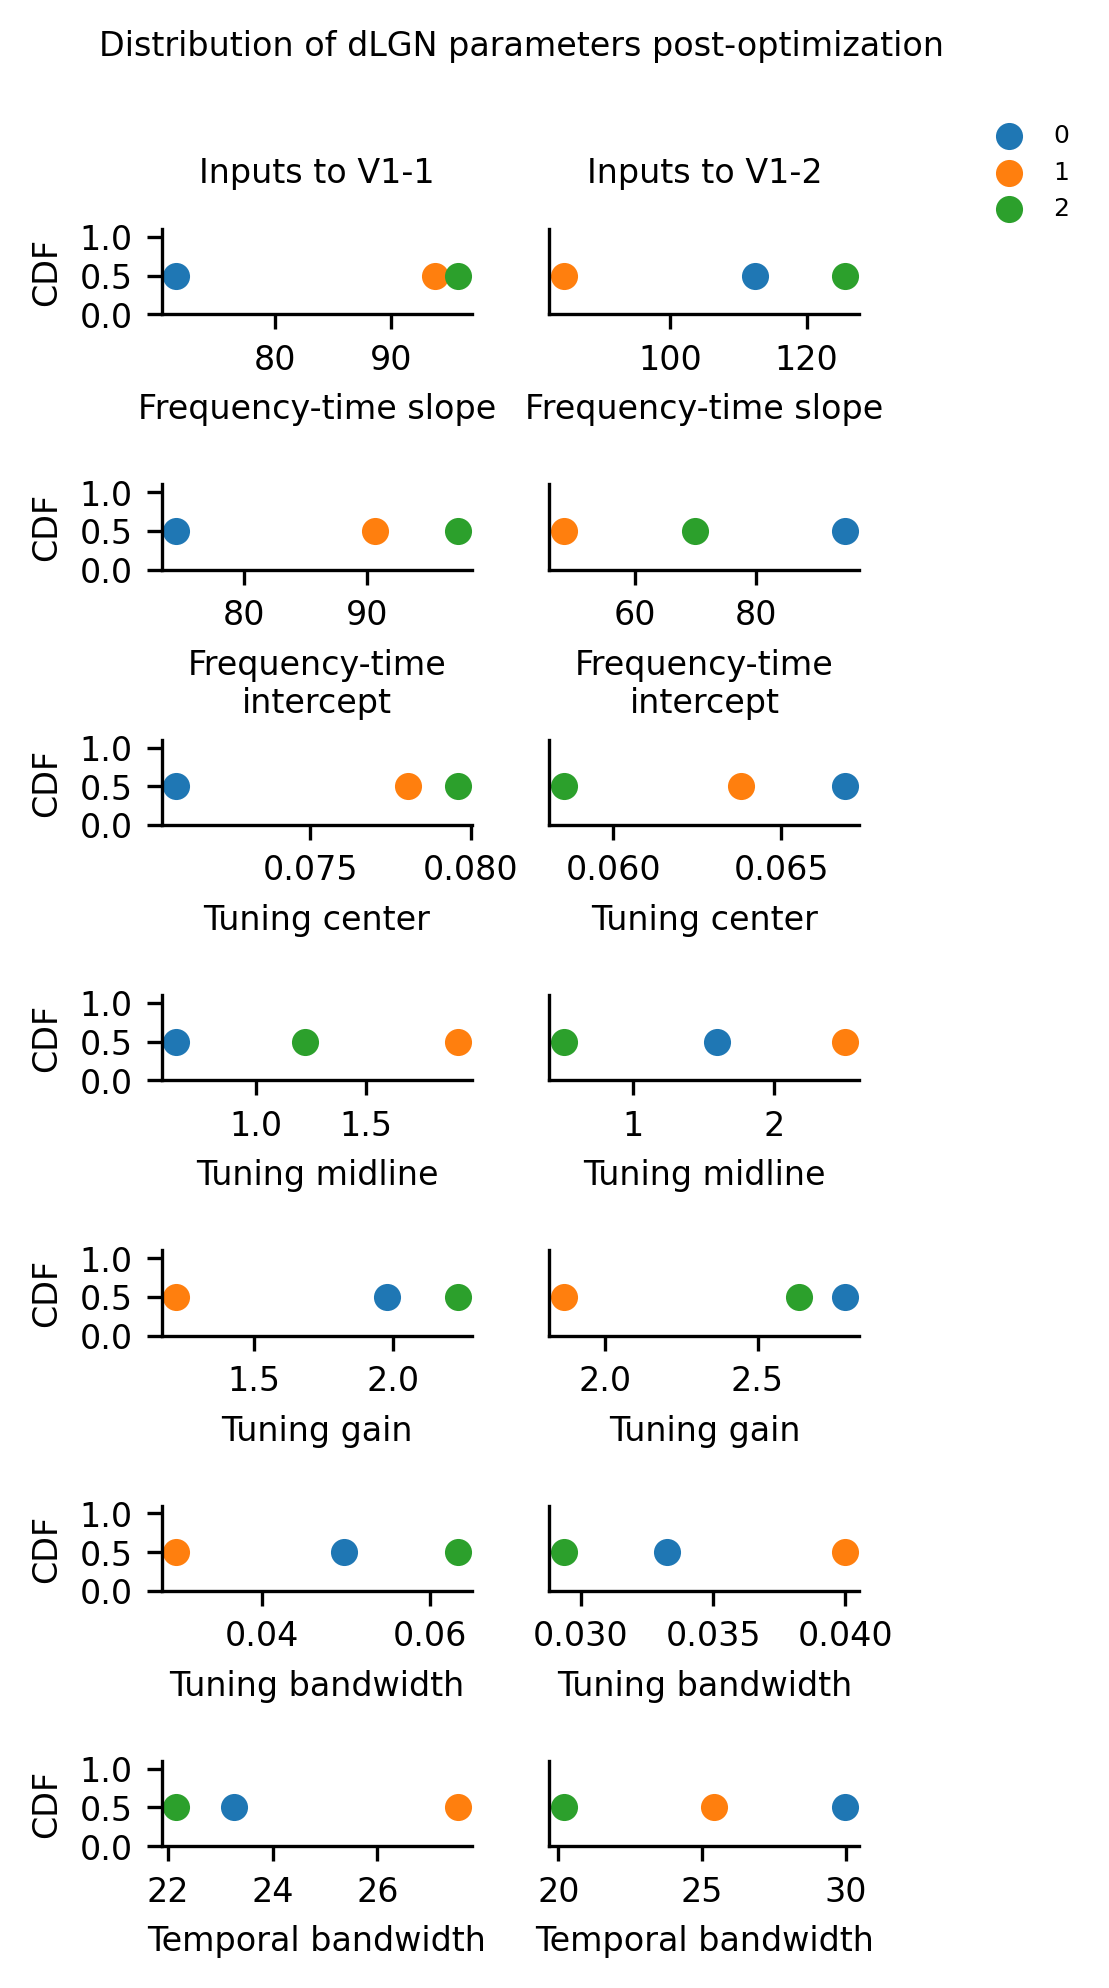

In [83]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(model2.params['dLGN_params'][0, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)
